In [1]:
from ml_enhance import load_hpc_result, compare
from ml_enhance import CorrelationFilter
from ml_enhance import FeatureImportance
from sklearn.base import BaseEstimator
from matplotlib.patches import Patch
import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
HuberReg_combo_filtered_df = load_hpc_result(Path("../data/HuberReg_results/HuberReg_combo_filtered_MSE_results.pkl"), "HuberReg_topo+QM_filtered")

In [3]:
HuberReg_topo_filtered_df = load_hpc_result(Path("../data/HuberReg_results/HuberReg_topo_filtered_MSE_results.pkl"), "HuberReg_topo_filtered")

In [4]:
HuberReg_combo_relevant_df = load_hpc_result(Path("../data/HuberReg_results/HuberReg_combo_relevant_results.pkl"), "HuberReg_topo+QM_relevant")

In [5]:
HuberReg_topo_relevant_df = load_hpc_result(Path("../data/HuberReg_results/HuberReg_topo_relevant_results.pkl"), "HuberReg_topo_relevant")

In [6]:
KRR_topo_filtered_df = load_hpc_result(Path("../data/KRR_results/KRR_topo_filtered_results.pkl"), "KRR_topo_filtered")

In [7]:
KRR_combo_filtered_df = load_hpc_result(Path("../data/KRR_results/KRR_combo_filtered_results.pkl"), "KRR_topo+QM_filtered")

In [9]:
KRR_topo_relevant_df = load_hpc_result(Path("../data/KRR_results/1_KRR_topo_relevant_results.pkl"), "KRR_topo_relevant")

In [10]:
KRR_combo_relevant_df = load_hpc_result(Path("../data/KRR_results/1_KRR_combo_relevant_results.pkl"), "KRR_topo+QM_relevant")

In [11]:
KRR_topo_relevant_no_norm_df = load_hpc_result(Path("../data/KRR_results/1_KRR_topo_relevant_no_norm_results.pkl"), "KRR_topo_relevant_no_norm")

In [12]:
KRR_combo_relevant_no_norm_df = load_hpc_result(Path("../data/KRR_results/1_KRR_combo_relevant_no_norm_results.pkl"), "KRR_topo+QM_relevant_no_norm")

In [13]:
RF_topo_filtered_df = load_hpc_result(Path("../data/RF_results/RF_topo_filtered_MSE_results.pkl"), "RF_topo")

In [14]:
RF_combo_filtered_df = load_hpc_result(Path("../data/RF_results/RF_combo_filtered_MSE_results.pkl"), "RF_topo+QM_filtered")

In [15]:
r2_df = pd.concat([df[["name", "test_r2"]] for df in [HuberReg_combo_filtered_df, HuberReg_topo_filtered_df, KRR_topo_filtered_df, KRR_combo_filtered_df, RF_topo_filtered_df, RF_combo_filtered_df]])

In [ ]:
# r2_df2 = pd.concat([df[["name", "test_r2"]] for df in [HuberReg_combo_relevant_df, HuberReg_topo_relevant_df, KRR_topo_relevant_df, KRR_combo_relevant_df, RF_topo_filtered_df, RF_combo_filtered_df]])

In [17]:
r2_df["group"] = r2_df["name"].str.extract(r"^(HuberReg|KRR|RF)")
r2_df["variant"] = r2_df["name"].str.extract(r"_(topo\+QM|topo)")

r2_df["variant"] = r2_df["variant"].replace({
    "topo": "Topo",
    "topo+QM": "Topo+QM"
})

In [18]:
r2_df2["group"] = r2_df2["name"].str.extract(r"^(HuberReg|KRR|RF)")
r2_df2["variant"] = r2_df2["name"].str.extract(r"_(topo\+QM|topo)")

r2_df2["variant"] = r2_df2["variant"].replace({
    "topo": "Topo",
    "topo+QM": "Topo+QM"
})

In [19]:
r2_df3 = pd.concat([df[["name", "test_r2"]] for df in [KRR_combo_filtered_df, KRR_topo_filtered_df, KRR_topo_relevant_df, KRR_combo_relevant_df, KRR_combo_relevant_no_norm_df, KRR_topo_relevant_no_norm_df]])

r2_df3["group"] = r2_df3["name"].str.extract(r"(filtered|relevant|norm)$")
r2_df3["variant"] = r2_df3["name"].str.extract(r"_(topo\+QM|topo)")

r2_df3["variant"] = r2_df3["variant"].replace({
    "topo": "Topo",
    "topo+QM": "Topo+QM"
})

In [20]:
r2_df

,name,test_r2,group,variant
fold_id,,,,
0,HuberReg_topo+QM_filtered,0.836093,HuberReg,Topo+QM
10,HuberReg_topo+QM_filtered,0.802331,HuberReg,Topo+QM
11,HuberReg_topo+QM_filtered,0.831067,HuberReg,Topo+QM
12,HuberReg_topo+QM_filtered,0.820733,HuberReg,Topo+QM
13,HuberReg_topo+QM_filtered,0.836394,HuberReg,Topo+QM
...,...,...,...,...
5,RF_topo+QM_filtered,0.866897,RF,Topo+QM
6,RF_topo+QM_filtered,0.866710,RF,Topo+QM
7,RF_topo+QM_filtered,0.872982,RF,Topo+QM


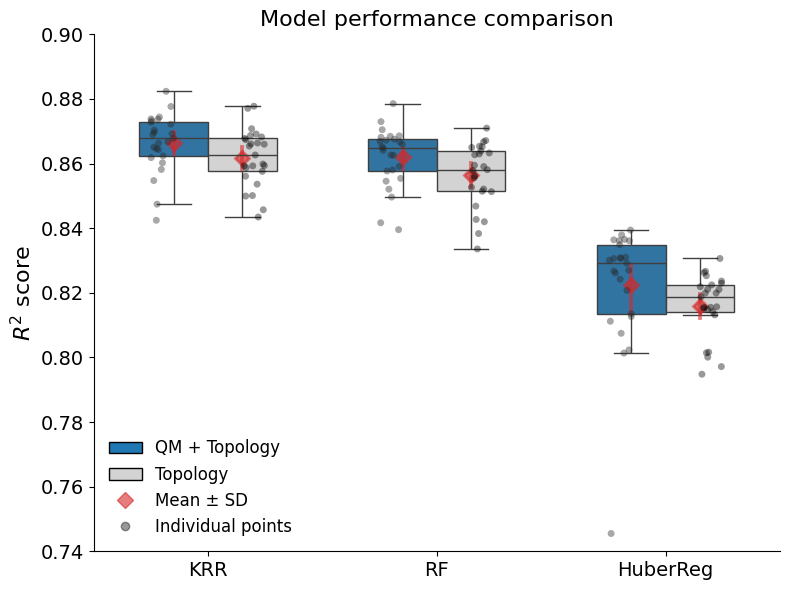

In [21]:
order = (
    r2_df.groupby("group")["test_r2"]
    .mean()
    .sort_values(ascending=False)
    .index
)

palette = {
    "Topo": "lightgray",
    "Topo+QM": "tab:blue"
}

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=r2_df,
    y="test_r2",
    x="group",
    order=order,
    palette=palette,
    hue="variant",
    width=0.6,
    fliersize=0
)

sns.pointplot(
    data=r2_df,
    y="test_r2",
    x="group",
    hue="variant",
    palette={"Topo": "tab:red", "Topo+QM": "tab:red"},
    order=order,
    dodge=0.3,
    linestyles="None",
    color="tab:red",
    markers="D",
    alpha=0.6
)

sns.stripplot(data=r2_df, x="group", y="test_r2", hue="variant", dodge=True, palette="dark:black", alpha=0.4)

strip_handle = mlines.Line2D(
    [], [],
    color="black",
    marker="o",
    linestyle="None",
    markersize=6,
    alpha=0.4,
    label="Individual points"
)

point_handle = mlines.Line2D(
    [], [],
    color="tab:red",
    alpha=0.6,
    marker="D",
    linestyle="None",
    markersize=8,
    label="Mean ± SD"
)

legend_elements = [
    Patch(facecolor="tab:blue", edgecolor="black", label="QM + Topology"),
    Patch(facecolor="lightgray", edgecolor="black", label="Topology"),
]

sns.despine(trim=False, left=False)

plt.legend(handles=legend_elements+[point_handle, strip_handle], loc="lower left", frameon=False, fontsize=12)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("")
plt.ylabel(r"$R^2$ score", fontsize=16)
plt.title("Model performance comparison", fontsize=16)
plt.ylim(0.74, 0.9)
plt.tight_layout()
# plt.savefig("HuberReg_compare.png", dpi=300)
plt.show()

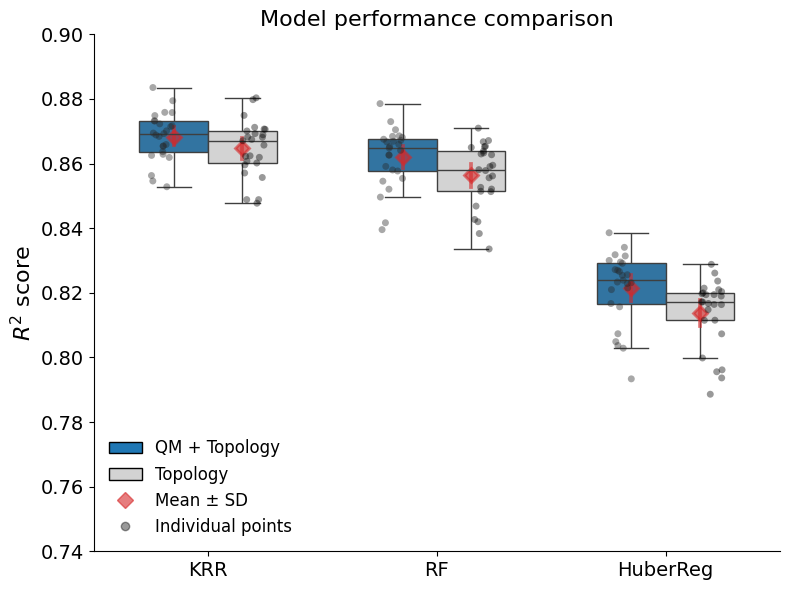

In [22]:
order = (
    r2_df2.groupby("group")["test_r2"]
    .mean()
    .sort_values(ascending=False)
    .index
)

palette = {
    "Topo": "lightgray",
    "Topo+QM": "tab:blue"
}

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=r2_df2,
    y="test_r2",
    x="group",
    order=order,
    palette=palette,
    hue="variant",
    width=0.6,
    fliersize=0
)

sns.pointplot(
    data=r2_df2,
    y="test_r2",
    x="group",
    hue="variant",
    palette={"Topo": "tab:red", "Topo+QM": "tab:red"},
    order=order,
    dodge=0.3,
    linestyles="None",
    color="tab:red",
    markers="D",
    alpha=0.6
)

sns.stripplot(data=r2_df2, x="group", y="test_r2", hue="variant", dodge=True, palette="dark:black", alpha=0.4)

strip_handle = mlines.Line2D(
    [], [],
    color="black",
    marker="o",
    linestyle="None",
    markersize=6,
    alpha=0.4,
    label="Individual points"
)

point_handle = mlines.Line2D(
    [], [],
    color="tab:red",
    alpha=0.6,
    marker="D",
    linestyle="None",
    markersize=8,
    label="Mean ± SD"
)

legend_elements = [
    Patch(facecolor="tab:blue", edgecolor="black", label="QM + Topology"),
    Patch(facecolor="lightgray", edgecolor="black", label="Topology"),
]

sns.despine(trim=False, left=False)

plt.legend(handles=legend_elements+[point_handle, strip_handle], loc="lower left", frameon=False, fontsize=12)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("")
plt.ylabel(r"$R^2$ score", fontsize=16)
plt.title("Model performance comparison", fontsize=16)
plt.ylim(0.74, 0.9)
plt.tight_layout()
# plt.savefig("HuberReg_compare.png", dpi=300)
plt.show()

In [23]:
order = (
    r2_df3.groupby("group")["test_r2"]
    .mean()
    .sort_values(ascending=False)
    .index
)
order

Index(['relevant', 'norm', 'filtered'], dtype='str', name='group')

In [24]:
r2_df3.head(50)

,name,test_r2,group,variant
fold_id,,,,
0,KRR_topo+QM_filtered,0.882363,filtered,Topo+QM
10,KRR_topo+QM_filtered,0.842455,filtered,Topo+QM
11,KRR_topo+QM_filtered,0.869682,filtered,Topo+QM
12,KRR_topo+QM_filtered,0.860243,filtered,Topo+QM
13,KRR_topo+QM_filtered,0.868996,filtered,Topo+QM
14,KRR_topo+QM_filtered,0.870361,filtered,Topo+QM
15,KRR_topo+QM_filtered,0.869226,filtered,Topo+QM
16,KRR_topo+QM_filtered,0.865081,filtered,Topo+QM
17,KRR_topo+QM_filtered,0.873732,filtered,Topo+QM


In [25]:
# compute mean per group
df_mean = (
    r2_df
    .groupby(["group", "variant"])["test_r2"]
    .mean()
    .unstack()
    .reset_index()
)
df_mean

variant,group,Topo,Topo+QM
0,HuberReg,0.815978,0.822347
1,KRR,0.861859,0.866426
2,RF,0.856421,0.861942


In [26]:
# compute mean per group
df_mean = (
    r2_df2
    .groupby(["group", "variant"])["test_r2"]
    .mean()
    .unstack()
    .reset_index()
)
df_mean

variant,group,Topo,Topo+QM
0,HuberReg,0.813662,0.821458
1,KRR,0.864710,0.868353
2,RF,0.856421,0.861942


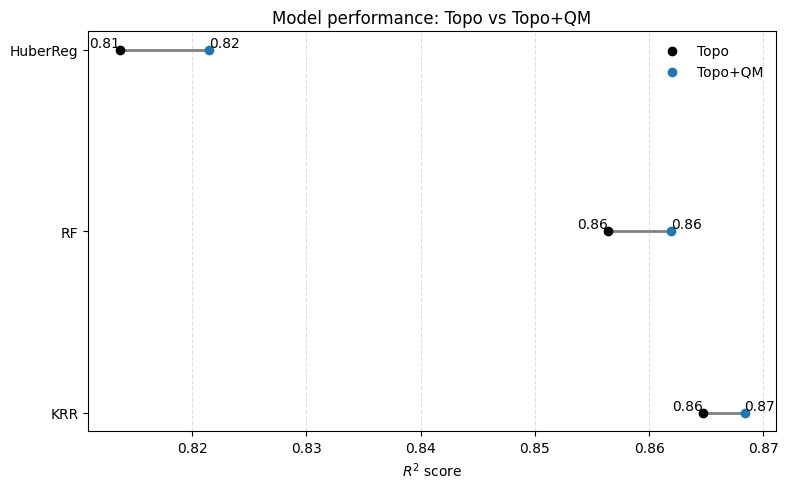

In [27]:
plt.figure(figsize=(8, 5))

# sort models by improvement (optional but nice)
df_mean["diff"] = df_mean["Topo+QM"] - df_mean["Topo"]
df_mean = df_mean.sort_values("diff")

y_pos = range(len(df_mean))

# draw lines (the "dumbbell sticks")
for i, row in enumerate(df_mean.itertuples()):
    plt.plot(
        [row.Topo, row._3],  # _3 = Topo+QM column
        [i, i],
        color="gray",
        linewidth=2,
        zorder=1
    )

# draw endpoints
plt.scatter(df_mean["Topo"], y_pos, color="black", label="Topo", zorder=2)
plt.scatter(df_mean["Topo+QM"], y_pos, color="tab:blue", label="Topo+QM", zorder=3)

for i, row in enumerate(df_mean.itertuples()):
    plt.text(row.Topo, i, f"{row.Topo:.2f}", va="bottom", ha="right")
    plt.text(row._3, i, f"{row._3:.2f}", va="bottom", ha="left")

# labels
plt.yticks(y_pos, df_mean["group"])
plt.xlabel(r"$R^2$ score")
plt.title("Model performance: Topo vs Topo+QM")

plt.legend(frameon=False)
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [28]:
from math import floor


n_train = floor(8763 * (4/5))
n_test = 8763 - n_train

In [29]:
compare(HuberReg_combo_filtered_df, HuberReg_topo_filtered_df, n_train=n_train, n_test=n_test)

HuberReg_topo+QM_filtered mean r2: 0.8223470906098259 (Train: 0.8414709048186713)
HuberReg_topo_filtered mean r2: 0.8159775612674507 (Train: 0.8278734281624573)
Mean improvement: 0.006369529342375126
T-test p-value: 0.11933052745423178 -> not statistically significant
Wilcoxon p-value: 7.49826431274414e-05 -> statistically significant


HuberReg_topo+QM_filtered mean MSE: 0.9456188950696632 (Train: 0.8443151757131194)
HuberReg_topo_filtered mean MSE: 0.9791662433193905 (Train: 0.916740987456218)
Mean improvement: -0.03354734824972709
T-test p-value: 0.12814257212838065 -> not statistically significant
Wilcoxon p-value: 7.49826431274414e-05 -> statistically significant




In [32]:
compare(HuberReg_combo_relevant_df, HuberReg_topo_relevant_df, n_train=n_train, n_test=n_test)

HuberReg_topo+QM_relevant mean r2: 0.8214584295455876 (Train: 0.8358944386590472)
HuberReg_topo_relevant mean r2: 0.8136617032388658 (Train: 0.8256317310041805)
Mean improvement: 0.007796726306721924
T-test p-value: 4.218847493575595e-15 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant


HuberReg_topo+QM_relevant mean MSE: 0.9498890828336074 (Train: 0.8740147759287342)
HuberReg_topo_relevant mean MSE: 0.9914246462058284 (Train: 0.9286752661190658)
Mean improvement: -0.0415355633722211
T-test p-value: 5.773159728050814e-15 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant




In [30]:
compare(KRR_combo_filtered_df, KRR_topo_filtered_df, n_train=n_train, n_test=n_test)

KRR_topo+QM_filtered mean r2: 0.8664257222583575 (Train: 0.9638596362853572)
KRR_topo_filtered mean r2: 0.8618590887947317 (Train: 0.9444404851024673)
Mean improvement: 0.00456663346362578
T-test p-value: 1.257062139048415e-06 -> statistically significant
Wilcoxon p-value: 2.562999725341797e-06 -> statistically significant


KRR_topo+QM_filtered mean MSE: 0.7108609977563617 (Train: 0.1924908312269966)
KRR_topo_filtered mean MSE: 0.735173663695551 (Train: 0.2959024890324815)
Mean improvement: -0.0243126659391895
T-test p-value: 1.1491350964121239e-06 -> statistically significant
Wilcoxon p-value: 2.562999725341797e-06 -> statistically significant




In [31]:
compare(RF_combo_filtered_df, RF_topo_filtered_df, n_train=n_train, n_test=n_test)

RF_topo+QM_filtered mean r2: 0.861941642782758 (Train: 0.9609099289437085)
RF_topo mean r2: 0.8564207097476007 (Train: 0.955647567672396)
Mean improvement: 0.005520933035157292
T-test p-value: 3.824829342136127e-11 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant


RF_topo+QM_filtered mean MSE: 0.7345208029193386 (Train: 0.2081940310111375)
RF_topo mean MSE: 0.7638703102971346 (Train: 0.23622132271142632)
Mean improvement: -0.02934950737779606
T-test p-value: 3.620637123447068e-11 -> statistically significant
Wilcoxon p-value: 5.960464477539063e-08 -> statistically significant




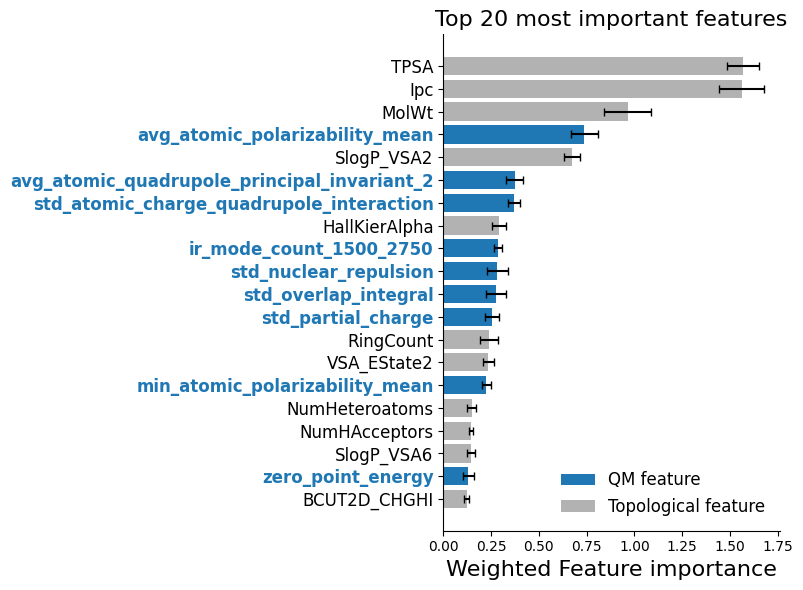

In [ ]:
FI = FeatureImportance(HuberReg_combo_filtered_df)
fi_df = FI.get_feature_importance(20)
FI.plot(20)

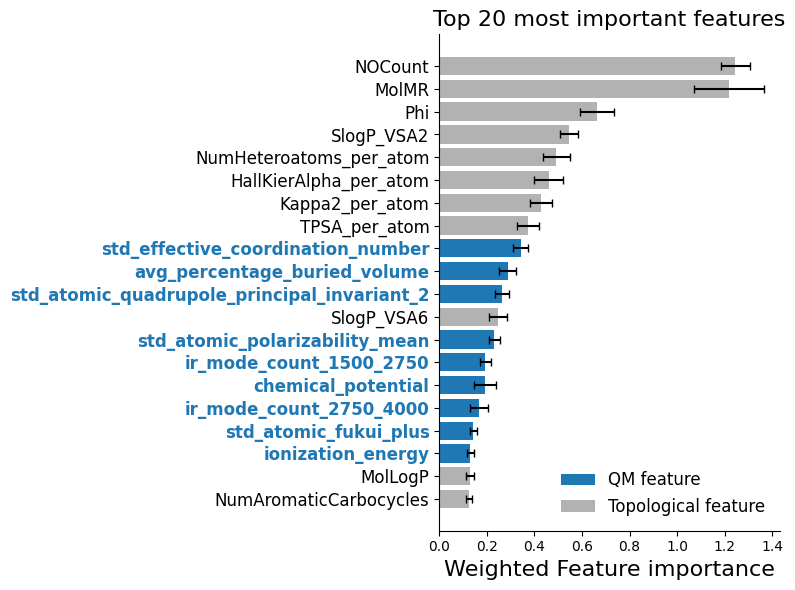

In [ ]:
FI = FeatureImportance(HuberReg_combo_relevant_df)
fi_df = FI.get_feature_importance(20)
FI.plot(20)

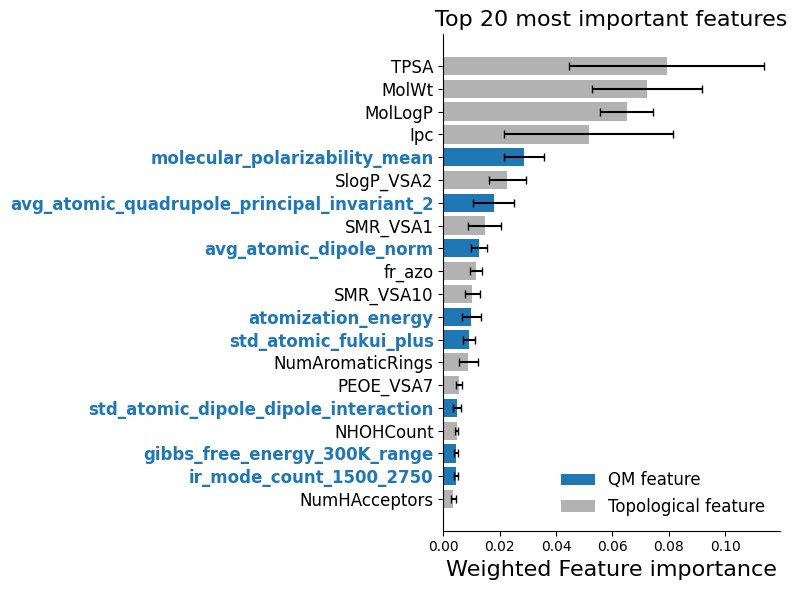

In [ ]:
file = Path(r"..\data\KRR_results\KRR_combo_filtered_PFI_results.pkl")
with file.open("rb") as f:
    data = pickle.load(f)

FI = FeatureImportance(KRR_combo_filtered_df, provided_FI=data)
fi_df = FI.get_feature_importance(20)
FI.plot(20)

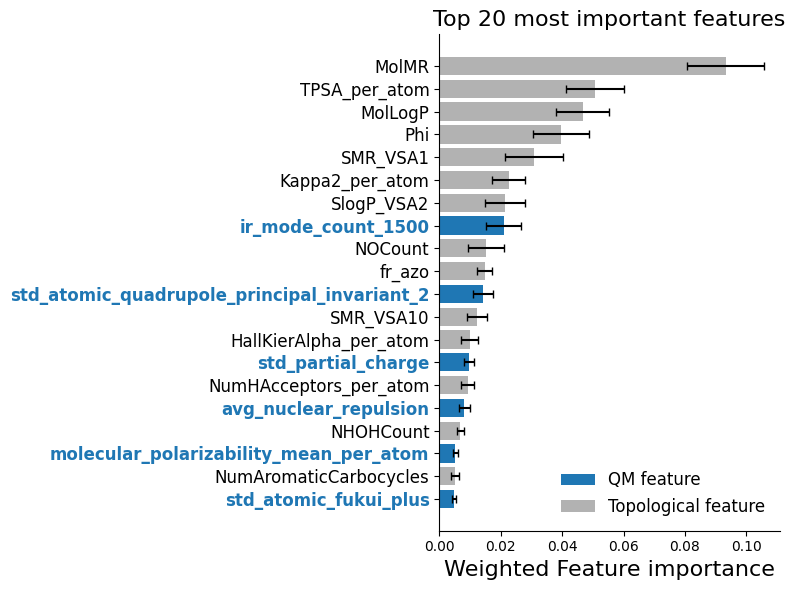

In [ ]:
file = Path(r"..\data\KRR_results\KRR_combo_relevant_PFI_results.pkl")
with file.open("rb") as f:
    data = pickle.load(f)

FI = FeatureImportance(KRR_combo_relevant_df, provided_FI=data)
fi_df = FI.get_feature_importance(20)
FI.plot(20)

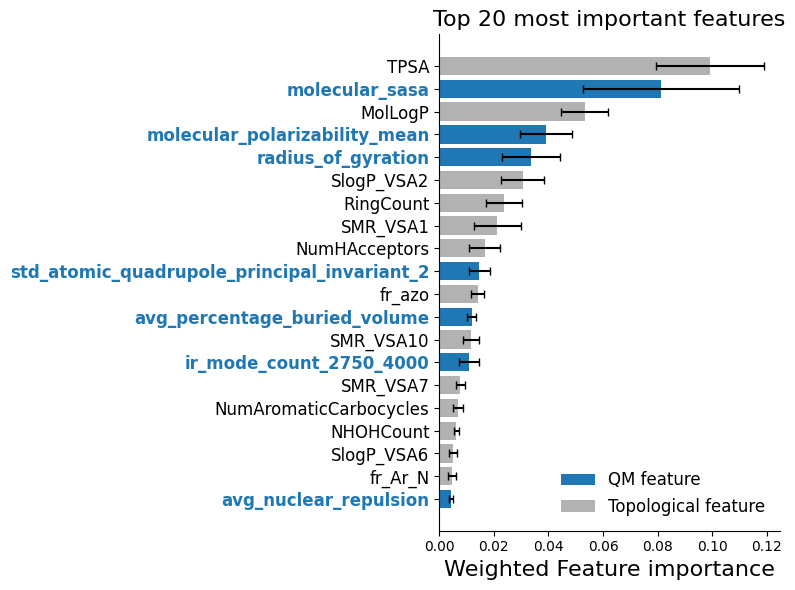

In [101]:
no_norm_data = pd.read_csv(r"..\data\KRR_results\1_KRR_combo_relevant_no_norm_PFI_results.csv")
no_norm_data
# grouped = no_norm_data[no_norm_data["fold_id"].isin(pos_folds)].groupby("size")
# data = grouped.get_group(size)
groups = no_norm_data[["fold_id", "feature", "r2_mean"]]
groups
FI_dict = {
    fold_id: df.set_index("feature")["r2_mean"]
    for fold_id, df in groups.groupby("fold_id")
}

FI = FeatureImportance(KRR_combo_relevant_df, provided_FI=FI_dict)
fi_df = FI.get_feature_importance(20)
FI.plot(20)

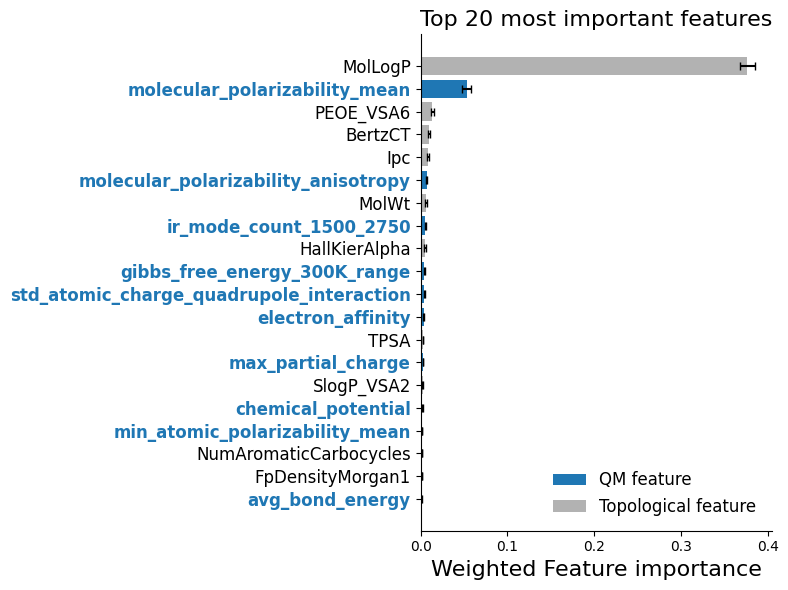

In [ ]:
from ml_enhance import FeatureImportance
import pickle

file = Path(r"..\data\RF_results\RF_combo_filtered_MSE_PFI_results.pkl")
with file.open("rb") as f:
    data = pickle.load(f)

FI = FeatureImportance(RF_combo_filtered_df, provided_FI=data)
fi_df = FI.get_feature_importance(20)
FI.plot(20)

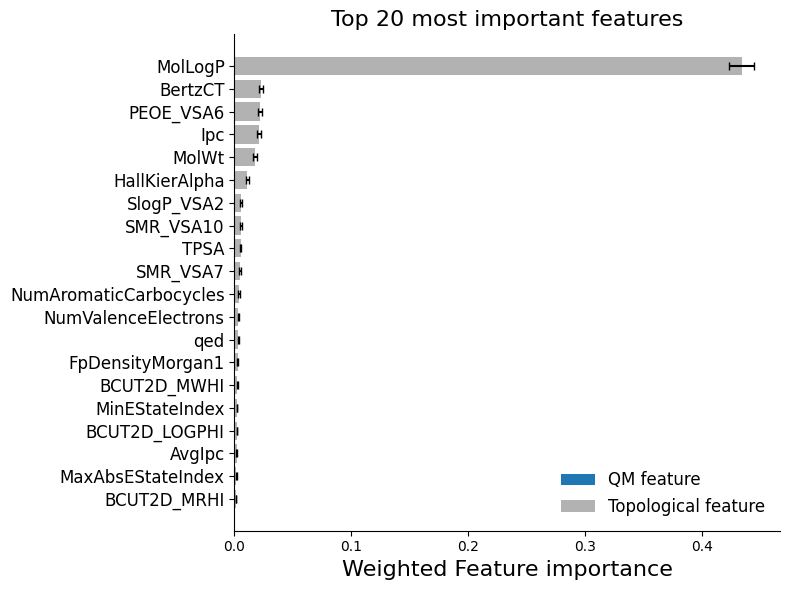

In [ ]:
from ml_enhance import FeatureImportance
import pickle

file = Path(r"..\data\RF_results\RF_topo_filtered_MSE_PFI_results.pkl")
with file.open("rb") as f:
    data = pickle.load(f)

FI = FeatureImportance(RF_topo_filtered_df, provided_FI=data)
fi_df = FI.get_feature_importance(20)
FI.plot(20)